<a href="https://colab.research.google.com/github/sudhersankv/gpu-programming/blob/main/inference-systems-notebooks/02_kv_cache_memory_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 1 — Learning goals

In Large Language Model (LLM) inference, the **KV Cache** (Key-Value Cache) is a crucial mechanism that prevents redundant computations.

### What is stored in the KV cache?
For every token processed, the attention mechanism computes a Key (K) and a Value (V) tensor. Instead of recalculating these tensors for past tokens every time a new token is generated, the system stores them in memory.

### Why keys and values must remain alive?
In autoregressive generation, predicting the next token requires attending to *all* previous tokens. If we discard the Keys and Values of earlier tokens, we would have to recompute them from scratch by running the entire sequence through the model again, which is computationally prohibitive.

### Why cache grows with context length?
Because every new token generated adds its own Key and Value vectors to the cache, the memory footprint increases linearly with every generation step.

### Why inference memory differs from training memory?
During training, memory is dominated by activations needed for backpropagation and optimizer states. During inference, backpropagation isn't needed, so intermediate activations can be discarded. However, inference introduces the stateful KV cache, which grows dynamically and can easily exceed the size of the model weights for long context windows.

## Section 2 — From one token to many

Let's visualize how the cache builds up conceptually.

### Start with one token:
When the first token is processed:
`Token 1` ↓
`[ K1, V1 ]` are generated and stored.

### 2 tokens:
For the second token, the model needs K1,V1 and computes K2,V2:
`Token 2` ↓
`[ K1, V1 ]`
`[ K2, V2 ]`

### N tokens:
As we generate up to N tokens, the memory strictly accumulates:
`Token N` ↓
`[ K1, V1 ]`
`[ K2, V2 ]`
...
`[ KN, VN ]`

Nothing can be discarded because the self-attention operation for token N+1 must compute the dot product between its Query vector and ALL previous Key vectors (1 through N), and then aggregate ALL previous Value vectors.

## Section 3 — Derive the memory equation

Let's calculate exactly how many bytes the KV cache consumes.

1. **One token, one head:**
   Each head produces a Key and a Value vector. The size of this vector is `head_dimension`. Since we have both K and V, that is `2 * head_dimension`.

2. **Multiple KV heads:**
   A model has `num_kv_heads` to process these. So, for one token in one layer: `2 * num_kv_heads * head_dimension`.

3. **Multiple layers:**
   This caching happens at *every* layer of the transformer. For one token across all layers: `2 * num_layers * num_kv_heads * head_dimension`.

4. **Multiple tokens (sequence length):**
   As the sequence grows to `sequence_length`, we multiply by this length: `2 * sequence_length * num_layers * num_kv_heads * head_dimension`.

5. **Batch size:**
   If we are processing `batch_size` requests concurrently, each needs its own cache: `2 * batch_size * sequence_length * num_layers * num_kv_heads * head_dimension`.

6. **Bytes per element:**
   Finally, the tensors are stored in a specific data type (like FP16, which uses 2 bytes per element). We multiply by `bytes_per_element` to get the final byte count.

**Final Formula:**
`KV Cache Bytes = 2 x batch_size x sequence_length x num_layers x num_kv_heads x head_dimension x bytes_per_element`

## Section 4 — Interactive estimator

Below is a Python function that implements our derived formula to calculate KV cache size. We will support different data types.

In [6]:
from typing import Dict, Union

def estimate_kv_cache_bytes(
    batch_size: int,
    sequence_length: int,
    num_layers: int,
    num_kv_heads: int,
    head_dim: int,
    dtype: str
) -> Dict[str, float]:
    """
    Estimates the KV cache memory size based on model and workload parameters.

    Args:
        batch_size: Number of concurrent sequences being processed.
        sequence_length: The length of the context (past tokens + current token).
        num_layers: Number of transformer layers.
        num_kv_heads: Number of attention heads dedicated to Keys and Values.
        head_dim: Dimensionality of each attention head.
        dtype: Data type of the cache (FP32, FP16, BF16, FP8, INT8).

    Returns:
        A dictionary containing the size in Bytes, MiB, and GiB.
    """
    # 1. Determine bytes per element based on the provided dtype string
    dtype = dtype.upper()
    if dtype == "FP32":
        bytes_per_element = 4
    elif dtype in ["FP16", "BF16"]:
        bytes_per_element = 2
    elif dtype in ["FP8", "INT8"]:
        bytes_per_element = 1
    else:
        raise ValueError(f"Unsupported dtype: {dtype}. Use FP32, FP16, BF16, FP8, or INT8.")

    # 2. Apply the derived formula
    # Factor of 2 is because we store BOTH Keys and Values.
    total_bytes = (
        2 *
        batch_size *
        sequence_length *
        num_layers *
        num_kv_heads *
        head_dim *
        bytes_per_element
    )

    # 3. Convert to human-readable formats (Binary prefix: 1024 based)
    bytes_in_mib = 1024 ** 2
    bytes_in_gib = 1024 ** 3

    return {
        "bytes": total_bytes,
        "MiB": total_bytes / bytes_in_mib,
        "GiB": total_bytes / bytes_in_gib
    }

# Test the function with a dummy calculation
print("Test calculation with gpt-oss-120b params - for 5 users, 32000 token each, 18 layers, 8 KV head, head_dim 64, FP16:")
print(estimate_kv_cache_bytes(5, 32000, 18, 8, 64, "FP16"))

Test calculation with gpt-oss-120b params - for 5 users, 32000 token each, 18 layers, 8 KV head, head_dim 64, FP16:
{'bytes': 5898240000, 'MiB': 5625.0, 'GiB': 5.4931640625}


## Section 5 — Real model examples

Now, let's use our estimator to analyze the KV cache footprints of several realistic architectures. We will use a Pandas DataFrame to nicely format the output.

In [7]:
import pandas as pd

# Define configurations for representative model sizes
# Note: Configurations are generalized approximations for educational purposes.
model_configs = [
    {
        "Model Profile": "Small (e.g., Llama-3-8B)",
        "num_layers": 32,
        "num_kv_heads": 8,   # Grouped Query Attention (GQA) reduces KV heads
        "head_dim": 128
    },
    {
        "Model Profile": "Medium (e.g., Llama-2-13B)",
        "num_layers": 40,
        "num_kv_heads": 40,  # Multi-Head Attention (MHA)
        "head_dim": 128
    },
    {
        "Model Profile": "Large (e.g., Llama-3-70B)",
        "num_layers": 80,
        "num_kv_heads": 8,   # GQA heavily used here to save memory
        "head_dim": 128
    },
    {
        "Model Profile": "Very Large (e.g., GPT-3 175B class)",
        "num_layers": 96,
        "num_kv_heads": 96,  # Dense MHA
        "head_dim": 128
    }
]

# Fixed parameters for this analysis
batch_size = 1
sequence_length = 4096 # Standard context
dtype = "FP16"

results = []

for config in model_configs:
    # Calculate memory
    mem_stats = estimate_kv_cache_bytes(
        batch_size=batch_size,
        sequence_length=sequence_length,
        num_layers=config["num_layers"],
        num_kv_heads=config["num_kv_heads"],
        head_dim=config["head_dim"],
        dtype=dtype
    )

    # Store results
    results.append({
        "Model": config["Model Profile"],
        "Layers": config["num_layers"],
        "KV Heads": config["num_kv_heads"],
        "Head Dim": config["head_dim"],
        "KV Cache (MiB)": round(mem_stats["MiB"], 2),
        "KV Cache (GiB)": round(mem_stats["GiB"], 2)
    })

df_models = pd.DataFrame(results)

# Let's also add a 'Long context' scenario for the Large model (e.g. 128k context)
long_ctx_mem = estimate_kv_cache_bytes(1, 131072, 80, 8, 128, "FP16")
df_models.loc[len(df_models)] = {
    "Model": "Large (Long Context 128k)",
    "Layers": 80,
    "KV Heads": 8,
    "Head Dim": 128,
    "KV Cache (MiB)": round(long_ctx_mem["MiB"], 2),
    "KV Cache (GiB)": round(long_ctx_mem["GiB"], 2)
}

display(df_models)

,Model,Layers,KV Heads,Head Dim,KV Cache (MiB),KV Cache (GiB)
0,"Small (e.g., Llama-3-8B)",32,8,128,512.0,0.50
1,"Medium (e.g., Llama-2-13B)",40,40,128,3200.0,3.12
2,"Large (e.g., Llama-3-70B)",80,8,128,1280.0,1.25
3,"Very Large (e.g., GPT-3 175B class)",96,96,128,18432.0,18.00
4,Large (Long Context 128k),80,8,128,40960.0,40.00


## Section 6 — Scaling experiments

We will now plot how the KV Cache memory scales as we independently change different parameters: Context Length, Batch Size, Layers, KV Heads, and Head Dimension. Each plot is independent.

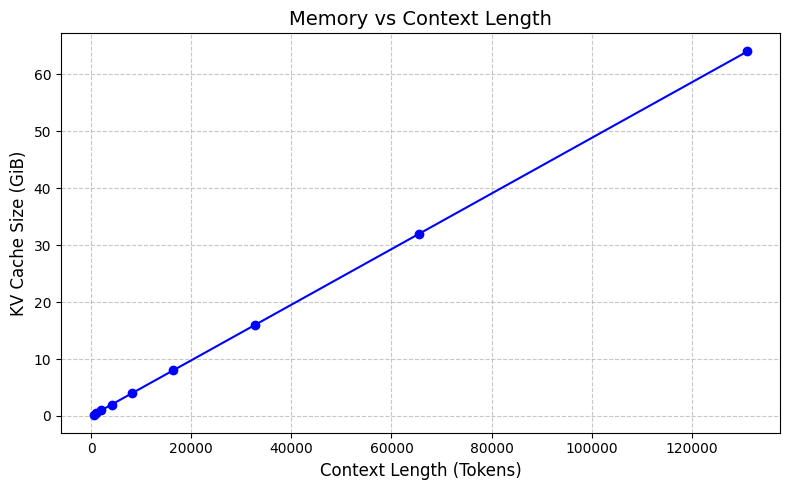

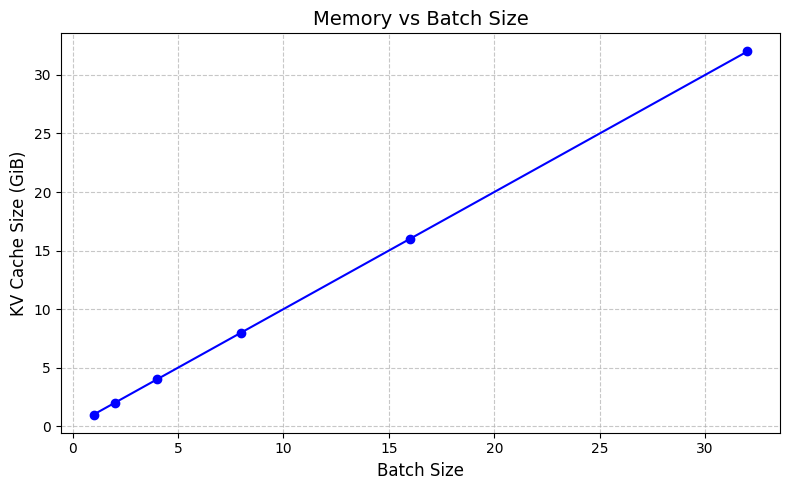

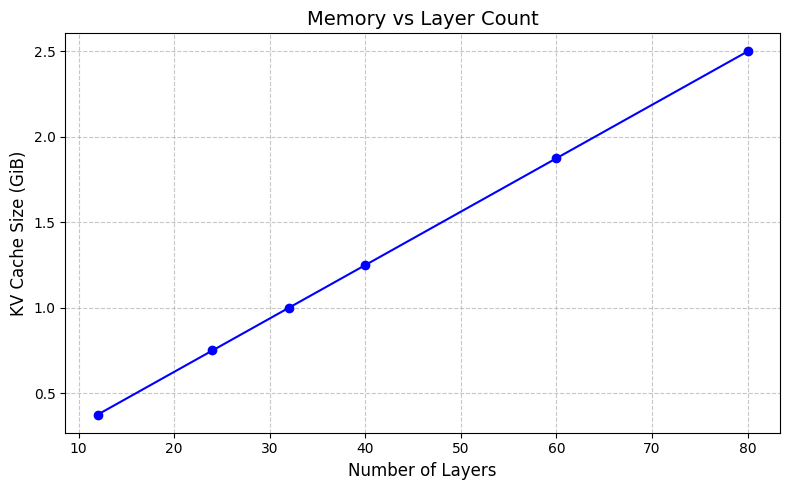

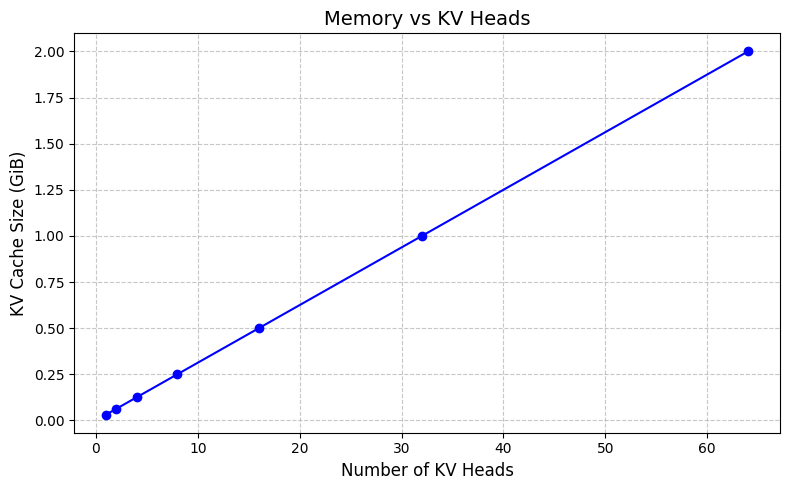

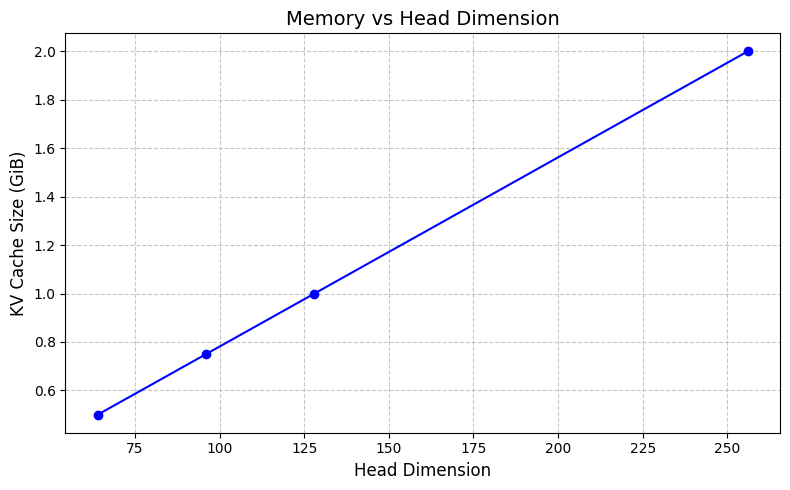

In [8]:
import matplotlib.pyplot as plt

# Base parameters for all experiments
base_batch = 1
base_seq = 2048
base_layers = 32
base_heads = 32
base_dim = 128
base_dtype = "FP16"

# Helper function to plot
def plot_scaling(x_values, y_values, x_label, title):
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker='o', linestyle='-', color='b')
    plt.title(title, fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel("KV Cache Size (GiB)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 1. Context Length Scaling
seq_lengths = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]
seq_memories = [estimate_kv_cache_bytes(base_batch, s, base_layers, base_heads, base_dim, base_dtype)["GiB"] for s in seq_lengths]
plot_scaling(seq_lengths, seq_memories, "Context Length (Tokens)", "Memory vs Context Length")

# 2. Batch Size Scaling
batch_sizes = [1, 2, 4, 8, 16, 32]
batch_memories = [estimate_kv_cache_bytes(b, base_seq, base_layers, base_heads, base_dim, base_dtype)["GiB"] for b in batch_sizes]
plot_scaling(batch_sizes, batch_memories, "Batch Size", "Memory vs Batch Size")

# 3. Layers Scaling
layer_counts = [12, 24, 32, 40, 60, 80]
layer_memories = [estimate_kv_cache_bytes(base_batch, base_seq, l, base_heads, base_dim, base_dtype)["GiB"] for l in layer_counts]
plot_scaling(layer_counts, layer_memories, "Number of Layers", "Memory vs Layer Count")

# 4. KV Heads Scaling
kv_heads_counts = [1, 2, 4, 8, 16, 32, 64]
heads_memories = [estimate_kv_cache_bytes(base_batch, base_seq, base_layers, h, base_dim, base_dtype)["GiB"] for h in kv_heads_counts]
plot_scaling(kv_heads_counts, heads_memories, "Number of KV Heads", "Memory vs KV Heads")

# 5. Head Dimension Scaling
head_dims = [64, 96, 128, 256]
dim_memories = [estimate_kv_cache_bytes(base_batch, base_seq, base_layers, base_heads, d, base_dtype)["GiB"] for d in head_dims]
plot_scaling(head_dims, dim_memories, "Head Dimension", "Memory vs Head Dimension")

## Section 7 — GPU capacity simulation

How long can our context be given a fixed GPU memory? We must reserve memory for model weights, forward activations, and the CUDA workspace. Whatever is left can be used for the KV Cache.

In [9]:
# GPU capacities in GiB
gpu_capacities_gib = [8, 16, 24, 48, 80]

# Assume a 14B parameter model in FP16 (approx 14B * 2 bytes = 28 GB, wait let's use a smaller 7B model for realistic fits)
# Let's use a 7B model: Weights = ~14 GiB.
weight_gib = 14.0
# Assume static memory overhead (Activations + CUDA workspace)
overhead_gib = 2.0

# Model architectural params for 7B
layers_7b = 32
kv_heads_7b = 32
head_dim_7b = 128
dtype_7b = "FP16"

# Bytes per token calculation for this model
# 2 (K+V) * 1 (batch) * 1 (token) * layers * kv_heads * head_dim * bytes_per_element
bytes_per_token = 2 * 1 * 1 * layers_7b * kv_heads_7b * head_dim_7b * 2
gib_per_token = bytes_per_token / (1024**3)

print(f"--- GPU Capacity Simulation for a 7B model ---")
print(f"Weights: {weight_gib} GiB | Overhead: {overhead_gib} GiB\n")

for cap in gpu_capacities_gib:
    remaining_gib = cap - weight_gib - overhead_gib

    if remaining_gib <= 0:
        print(f"GPU: {cap} GB -> OOM! Cannot even fit model weights.")
    else:
        max_tokens = int(remaining_gib / gib_per_token)
        print(f"GPU: {cap} GB -> Free for KV: {remaining_gib:5.1f} GiB -> Max Context: ~{max_tokens:,} tokens")

--- GPU Capacity Simulation for a 7B model ---
Weights: 14.0 GiB | Overhead: 2.0 GiB

GPU: 8 GB -> OOM! Cannot even fit model weights.
GPU: 16 GB -> OOM! Cannot even fit model weights.
GPU: 24 GB -> Free for KV:   8.0 GiB -> Max Context: ~16,384 tokens
GPU: 48 GB -> Free for KV:  32.0 GiB -> Max Context: ~65,536 tokens
GPU: 80 GB -> Free for KV:  64.0 GiB -> Max Context: ~131,072 tokens


## Section 8 — Why decode becomes memory-bound

Text generation occurs in two phases:
1. **Prefill**: Processes the prompt. Computes lots of K/V matrices at once. This uses large matrix multiplications, fully utilizing the GPU's compute cores (Compute-bound).
2. **Decode**: Generates token by token.

### The Decode Bottleneck:
During decoding, generating *one* new token requires reading the *entire* past KV cache from memory to the GPU compute cores to perform attention.

`Token 1` ↓
Read 1 KV

`Token 1000` ↓
Read 1000 KV

`Token 5000` ↓
Read 5000 KV

Even though the math (compute) required for one token is tiny, the system must transfer gigabytes of KV cache data across the GPU memory bus for *every single token*. Therefore, generation slows down as context grows because it is waiting on **memory bandwidth**, not compute power.

## Section 9 — Memory pressure simulation

In a real serving environment, we don't just process one request. We process many, and they start and finish at different times. If we pre-allocate the maximum possible size for every request, we waste memory. If we dynamically allocate, we risk running out of blocks (OOM).

Let's simulate a basic block allocation scenario with simple eviction.

In [10]:
class BasicKVCacheManager:
    def __init__(self, total_blocks: int):
        self.total_blocks = total_blocks
        self.used_blocks = 0
        self.allocations = {} # request_id -> block_count

    def allocate(self, req_id: str, blocks_needed: int):
        if self.used_blocks + blocks_needed <= self.total_blocks:
            self.allocations[req_id] = blocks_needed
            self.used_blocks += blocks_needed
            print(f"Allocated {blocks_needed} blocks for {req_id}. Free blocks: {self.get_free_blocks()}")
            return True
        else:
            print(f"FAILURE: Cannot allocate {blocks_needed} blocks for {req_id}. Out of memory!")
            return False

    def get_free_blocks(self):
        return self.total_blocks - self.used_blocks

    def evict(self, req_id: str):
        if req_id in self.allocations:
            blocks_freed = self.allocations.pop(req_id)
            self.used_blocks -= blocks_freed
            print(f"Evicted {req_id}, freed {blocks_freed} blocks. Free blocks: {self.get_free_blocks()}")

# Simulation Setup
total_gpu_blocks = 100
manager = BasicKVCacheManager(total_gpu_blocks)

print("--- Starting Allocation ---")
# 1. Allocate Request A (40 blocks)
manager.allocate("Request A", 40)

# 2. Allocate Request B (25 blocks)
manager.allocate("Request B", 25)

# 3. Try Request C (50 blocks) - Should fail
manager.allocate("Request C", 50)

# 4. Introduce Eviction: Evict A to make room for C
print("\n--- Running Eviction ---")
manager.evict("Request A")
manager.allocate("Request C", 50)

--- Starting Allocation ---
Allocated 40 blocks for Request A. Free blocks: 60
Allocated 25 blocks for Request B. Free blocks: 35
FAILURE: Cannot allocate 50 blocks for Request C. Out of memory!

--- Running Eviction ---
Evicted Request A, freed 40 blocks. Free blocks: 75
Allocated 50 blocks for Request C. Free blocks: 25


True

## Section 10 — Why inference runtimes exist

Our toy simulations demonstrate severe inefficiencies:
*   Memory grows linearly and uncontrollably.
*   Requests fail if contiguous memory runs out.
*   Decode gets severely slowed down by memory bandwidth due to reading the massive cache.

This is why modern inference frameworks exist. They solve these problems using advanced techniques (which we will cover in future notebooks):

*   **PagedAttention (vLLM):** Breaks the KV cache into fixed-size, non-contiguous blocks (like OS virtual memory). Eliminates fragmentation.
*   **Prefix caching (RadixAttention/SGLang):** Shares the KV cache of identical prompts (like system prompts) across multiple requests.
*   **LMCache:** Introduces a global, distributed KV cache to share across multiple inference nodes.
*   **KV quantization:** Compresses the cache from FP16 to FP8 or INT8 to cut memory footprint and bandwidth requirements by half or more.

## Section 11 — Knowledge check

<details>
<summary><b>1. Why does KV grow linearly?</b></summary>
Because every token generated produces one Key and one Value vector, which are strictly appended to the cache. The number of stored vectors equals the number of processed tokens.
</details>

<details>
<summary><b>2. Why doesn't model size appear directly in the KV formula?</b></summary>
Model size (parameters) defines the weight footprint. The KV cache footprint depends on the *architecture dimensions* (layers, heads, head_dim) and *workload* (batch, sequence), not the hidden MLP parameters.
</details>

<details>
<summary><b>3. Why do grouped-query attention (GQA) models use less KV memory?</b></summary>
GQA drastically reduces the number of `num_kv_heads` relative to query heads. As seen in the formula, fewer KV heads linearly decreases cache size.
</details>

<details>
<summary><b>4. Why is decode more memory-intensive than prefill?</b></summary>
Decode reads the entire history of KV cache from GPU memory for every single generated token, making it heavily bound by memory bandwidth, whereas prefill calculates them in parallel (compute-bound).
</details>

<details>
<summary><b>5. Would doubling sequence length double compute?</b></summary>
During prefill, attention compute scales quadratically with sequence length. However, KV memory size scales strictly linearly.
</details>

<details>
<summary><b>6. Would doubling layers double KV?</b></summary>
Yes, because the cache stores Keys and Values for every single transformer layer. Doubling layers doubles the caching requirements.
</details>

<details>
<summary><b>7. Why can't we discard old KV vectors?</b></summary>
Autoregressive attention requires calculating attention scores over the entire sequence history. Missing vectors would make calculating accurate attention impossible.
</details>

<details>
<summary><b>8. Does batch size affect cache per request?</b></summary>
No, cache *per request* is independent, but total cache on the GPU scales linearly with batch size because every request maintains its own independent state.
</details>

<details>
<summary><b>9. What happens when the GPU runs out of free memory for KV cache?</b></summary>
The system cannot generate the next token and will typically result in an Out-of-Memory (OOM) error, or the system must evict the request to CPU/disk or abort it.
</details>

<details>
<summary><b>10. How does INT8 quantization help?</b></summary>
It cuts the `bytes_per_element` in half compared to FP16, immediately halving both the GPU memory consumed and the memory bandwidth required during decoding.
</details>

## Section 12 — Final takeaway

KV cache memory grows linearly with:
- `batch size`
- `sequence length`
- `layers`
- `KV heads`
- `head dimension`

The cache enables fast decoding by avoiding massive recomputation, but it consumes continuously increasing memory as the context window grows.

Modern inference runtimes exist largely to manage this KV memory efficiently through paging, reuse, compression, and multi-tier storage.